## 跨数据集热力图

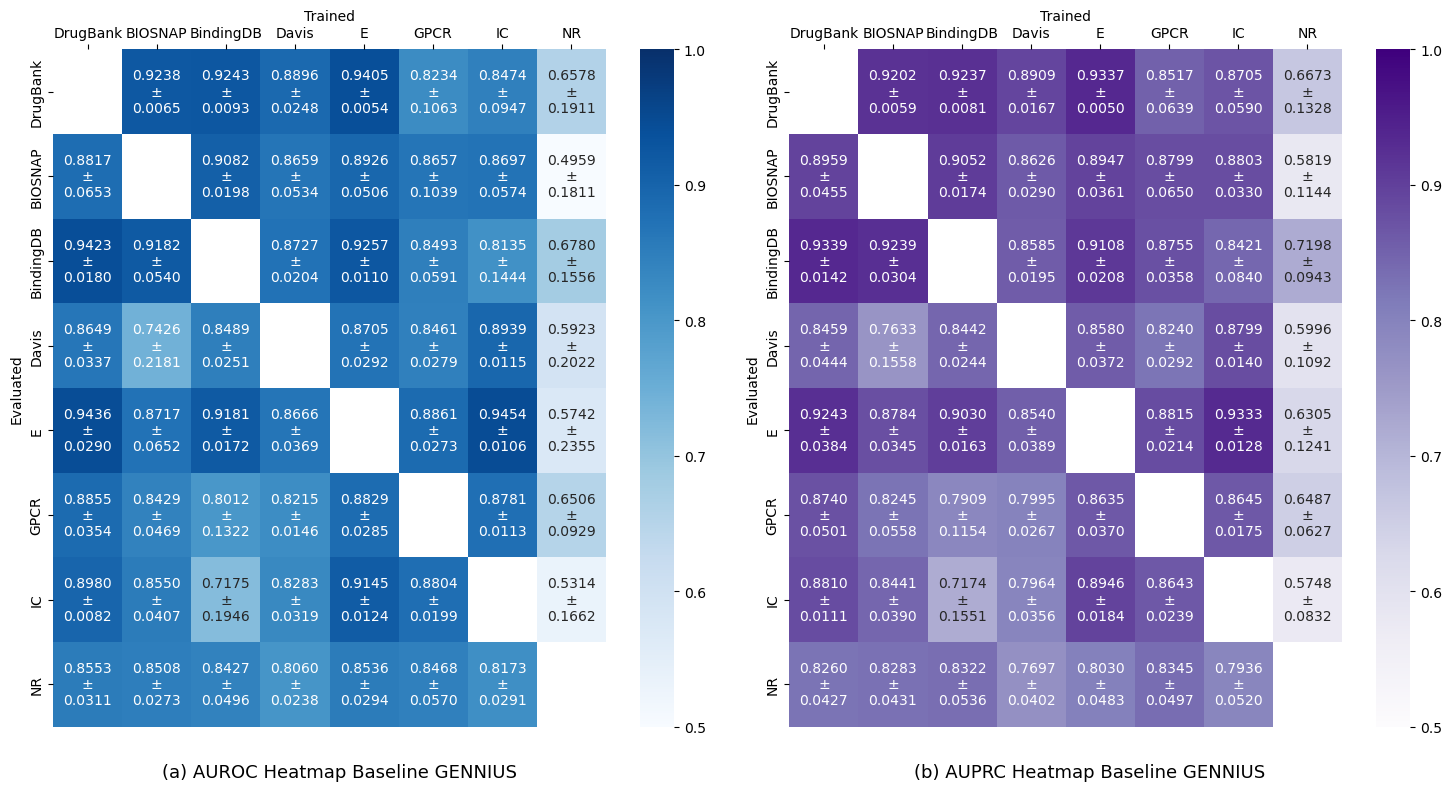

OK!!!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

datasets = ['DrugBank', 'BIOSNAP', 'BindingDB', 'Davis', 'E', 'GPCR', 'IC', 'NR']

# 示例数据（请替换为你的真实数据），对角线填 np.nan
auroc_mean = np.array([
    [np.nan, 0.9238, 0.9243, 0.8896, 0.9405, 0.8234, 0.8474, 0.6578],
    [0.8817, np.nan, 0.9082, 0.8659, 0.8926, 0.8657, 0.8697, 0.4959],
    [0.9423, 0.9182, np.nan, 0.8727, 0.9257, 0.8493, 0.8135, 0.6780],
    [0.8649, 0.7426, 0.8489, np.nan, 0.8705, 0.8461, 0.8939, 0.5923],
    [0.9436, 0.8717, 0.9181, 0.8666, np.nan, 0.8861, 0.9454, 0.5742],
    [0.8855, 0.8429, 0.8012, 0.8215, 0.8829, np.nan, 0.8781, 0.6506],
    [0.8980, 0.8550, 0.7175, 0.8283, 0.9145, 0.8804, np.nan, 0.5314],
    [0.8553, 0.8508, 0.8427, 0.8060, 0.8536, 0.8468, 0.8173, np.nan]
])

auroc_std = np.array([
    [np.nan, 0.0065, 0.0093, 0.0248, 0.0054, 0.1063, 0.0947, 0.1911],
    [0.0653, np.nan, 0.0198, 0.0534, 0.0506, 0.1039, 0.0574, 0.1811],
    [0.0180, 0.0540, np.nan, 0.0204, 0.0110, 0.0591, 0.1444, 0.1556],
    [0.0337, 0.2181, 0.0251, np.nan, 0.0292, 0.0279, 0.0115, 0.2022],
    [0.0290, 0.0652, 0.0172, 0.0369, np.nan, 0.0273, 0.0106, 0.2355],
    [0.0354, 0.0469, 0.1322, 0.0146, 0.0285, np.nan, 0.0113, 0.0929],
    [0.0082, 0.0407, 0.1946, 0.0319, 0.0124, 0.0199, np.nan, 0.1662],
    [0.0311, 0.0273, 0.0496, 0.0238, 0.0294, 0.0570, 0.0291, np.nan]
])

auprc_mean = np.array([
    [np.nan, 0.9202, 0.9237, 0.8909, 0.9337, 0.8517, 0.8705, 0.6673],
    [0.8959, np.nan, 0.9052, 0.8626, 0.8947, 0.8799, 0.8803, 0.5819],
    [0.9339, 0.9239, np.nan, 0.8585, 0.9108, 0.8755, 0.8421, 0.7198],
    [0.8459, 0.7633, 0.8442, np.nan, 0.8580, 0.8240, 0.8799, 0.5996],
    [0.9243, 0.8784, 0.9030, 0.8540, np.nan, 0.8815, 0.9333, 0.6305],
    [0.8740, 0.8245, 0.7909, 0.7995, 0.8635, np.nan, 0.8645, 0.6487],
    [0.8810, 0.8441, 0.7174, 0.7964, 0.8946, 0.8643, np.nan, 0.5748],
    [0.8260, 0.8283, 0.8322, 0.7697, 0.8030, 0.8345, 0.7936, np.nan]
])

auprc_std = np.array([
    [np.nan, 0.0059, 0.0081, 0.0167, 0.0050, 0.0639, 0.0590, 0.1328],
    [0.0455, np.nan, 0.0174, 0.0290, 0.0361, 0.0650, 0.0330, 0.1144],
    [0.0142, 0.0304, np.nan, 0.0195, 0.0208, 0.0358, 0.0840, 0.0943],
    [0.0444, 0.1558, 0.0244, np.nan, 0.0372, 0.0292, 0.0140, 0.1092],
    [0.0384, 0.0345, 0.0163, 0.0389, np.nan, 0.0214, 0.0128, 0.1241],
    [0.0501, 0.0558, 0.1154, 0.0267, 0.0370, np.nan, 0.0175, 0.0627],
    [0.0111, 0.0390, 0.1551, 0.0356, 0.0184, 0.0239, np.nan, 0.0832],
    [0.0427, 0.0431, 0.0536, 0.0402, 0.0483, 0.0497, 0.0520, np.nan]
])
def get_annot_multiline(mean, std):
    annot = mean.astype(str)
    for i in range(mean.shape[0]):
        for j in range(mean.shape[1]):
            if np.isnan(mean[i, j]):
                annot[i, j] = ''
            else:
                annot[i, j] = f"{mean[i,j]:.4f}\n±\n{std[i,j]:.4f}"
    return annot

fig, axes = plt.subplots(1, 2, figsize=(15, 9))

cmap_auroc = matplotlib.colormaps['Blues'].copy()
cmap_auroc.set_bad(color='white')  # 让 np.nan 变成纯白色

cmap_auprc = matplotlib.colormaps['Purples'].copy()
cmap_auprc.set_bad(color='white')


# AUROC Heatmap
sns.heatmap(
    auroc_mean,
    annot=get_annot_multiline(auroc_mean, auroc_std),
    fmt='',
    cmap=cmap_auroc,
    vmin=0.5,
    vmax=1.0,
    ax=axes[0],
    cbar_kws={'label': ''}
)
axes[0].set_xticklabels(datasets, rotation=0, ha='center')
axes[0].set_yticklabels(datasets, rotation=90)
axes[0].yaxis.set_ticks_position('left')
axes[0].set_xlabel('')  # 不显示下方x label
axes[0].set_ylabel('Evaluated')
axes[0].xaxis.set_ticks_position('top')  # 标签放顶部
axes[0].xaxis.set_label_position('top')  # x轴label（如Trained）也放顶部
axes[0].set_title('', fontsize=16)
# 插入顶部 "Trained"
axes[0].set_xlabel('Trained')

fig.text(0.23, 0.13, '(a) AUROC Heatmap Baseline GENNIUS', fontsize=13, ha='center')

# AUPRC Heatmap
sns.heatmap(
    auprc_mean,
    annot=get_annot_multiline(auprc_mean, auprc_std),
    fmt='',
    cmap=cmap_auprc,
    vmin=0.5,
    vmax=1.0,
    ax=axes[1],
    cbar_kws={'label': ''}
)
axes[1].set_xticklabels(datasets, rotation=0, ha='center')
axes[1].set_yticklabels(datasets, rotation=90)
axes[1].yaxis.set_ticks_position('left')
axes[1].set_xlabel('')
axes[1].set_ylabel('Evaluated')
axes[1].xaxis.set_ticks_position('top')
axes[1].xaxis.set_label_position('top')
axes[1].set_title('', fontsize=16)
axes[1].set_xlabel('Trained')

fig.text(0.73, 0.13, '(b) AUPRC Heatmap Baseline GENNIUS', fontsize=13, ha='center')

plt.tight_layout(rect=[0, 0.16, 1, 1])
plt.show()
print("OK!!!")
# plt.show()

## 双变量折线图

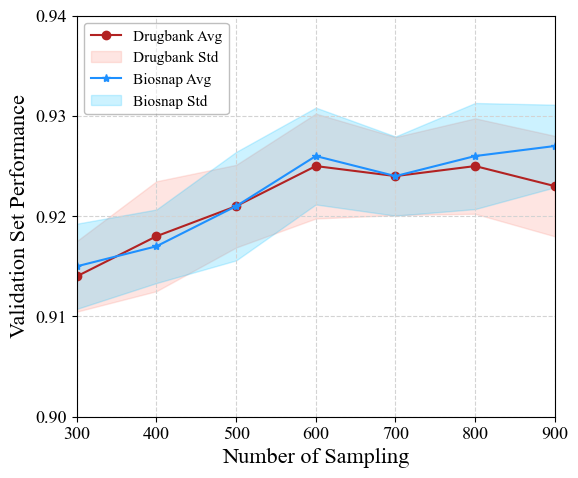

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator

# 核心修复：重置 matplotlib 样式，防止 IDE 深色模式将字体变成白色
plt.style.use('default')

font1 = {'family': 'Times New Roman', 'weight': 'normal', 'size': 16}
font3 = {'family': 'Times New Roman', 'weight': 'normal', 'size': 11}

embedding_dims = [300, 400, 500, 600, 700, 800, 900]
embed_results1 = [0.914, 0.918, 0.921, 0.925, 0.924, 0.925, 0.923]
embed_stds1 = [0.00352, 0.00548, 0.00412, 0.00523, 0.00389, 0.00476, 0.00501]

embed_results2 = [0.915, 0.917, 0.921, 0.926, 0.924, 0.926, 0.927]
embed_stds2 = [0.00425, 0.00367, 0.00541, 0.00483, 0.00395, 0.00529, 0.00412]

N_embed = len(embedding_dims)
x_embed = np.linspace(0, 1, N_embed)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# 显式设置所有文字的颜色为黑色，以防万一
ax.tick_params(axis='both', colors='black', labelsize=16)

ax.set_xticks(x_embed)
ax.set_xticklabels([str(d) for d in embedding_dims])
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.grid(linestyle="--")
ax.set_xlim(0, 1)
ax.set_ylim(0.90, 0.94)
ax.tick_params(labelsize=13)

# 尝试应用字体，如果环境缺少该字体会有警告但不会白屏
labels = ax.get_xticklabels() + ax.get_yticklabels()
try:
    [label.set_fontname('Times New Roman') for label in labels]
except Exception as e:
    print(f"字体设置警告: {e}")

ax.plot(x_embed, embed_results1, marker='o', color="firebrick", label='Drugbank Avg')
ax.fill_between(x_embed, np.array(embed_results1)-np.array(embed_stds1),
                np.array(embed_results1)+np.array(embed_stds1),
                color='salmon', alpha=0.2, label='Drugbank Std')

ax.plot(x_embed, embed_results2, marker='*', color="dodgerblue", label='Biosnap Avg')
ax.fill_between(x_embed, np.array(embed_results2)-np.array(embed_stds2),
                np.array(embed_results2)+np.array(embed_stds2),
                color='deepskyblue', alpha=0.2, label='Biosnap Std')

ax.set_xlabel("Number of Sampling", fontdict=font1, color='black')
ax.set_ylabel("Validation Set Performance", fontdict=font1, color='black')
ax.legend(loc="upper left", prop=font3, frameon=True, facecolor='white',
          edgecolor='gray', framealpha=0.5, labelcolor='black')

# 设置背景与边框
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.grid(linestyle="--", color='lightgray', linewidth=0.8)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8)

# 将 pad=3.0 改小一点，避免在 6x5 的画布上把图表挤压得太厉害
plt.tight_layout(pad=1.5)

plt.show()

## 柱状图

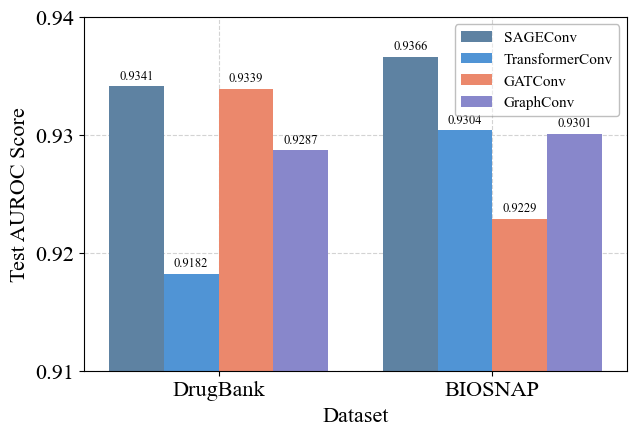

OK!!!


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import MultipleLocator

# =======================
# 数据
# =======================
datasets = ['DrugBank', 'BIOSNAP']
conv_methods = ['SAGEConv', 'TransformerConv', 'GATConv', 'GraphConv']

data = {
    'DrugBank': [0.9341, 0.9182, 0.9339, 0.9287],
    'BIOSNAP':  [0.9366, 0.9304, 0.9229, 0.9301]
}

# =======================
# 字体设置（保持全局一致）
# =======================
font1 = {'family': 'Times New Roman', 'weight': 'normal', 'size': 16}
font3 = {'family': 'Times New Roman', 'weight': 'normal', 'size': 11}

# =======================
# 画布
# =======================
fig, ax = plt.subplots(figsize=(7, 5))

# =======================
# 柱状图设置（保持你的原色）
# =======================
x = np.arange(len(datasets))
width = 0.2
colors = ['#5E82A2', '#5094D5', '#EB886C', '#8887CB']

for i, method in enumerate(conv_methods):
    positions = x + (i - 1.5) * width
    values = [data['DrugBank'][i], data['BIOSNAP'][i]]

    bars = ax.bar(positions, values, width, label=method, color=colors[i])

    # === 柱体数值 ===
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9,
                    fontname='Times New Roman')

# =======================
# 坐标轴
# =======================
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel('Dataset', fontdict=font1)
ax.set_ylabel('Test AUROC Score', fontdict=font1)

ax.set_xticks(x)
ax.set_xticklabels(datasets, fontname='Times New Roman')

# y 轴刻度与前图保持一致
ax.set_ylim(0.91, 0.94)
ax.yaxis.set_major_locator(MultipleLocator(0.01))

# 字体统一
labels = ax.get_xticklabels() + ax.get_yticklabels()
[label.set_fontname('Times New Roman') for label in labels]

# =======================
# 网格（完全一致）
# =======================
ax.grid(linestyle="--", color='lightgray', linewidth=0.8)
ax.set_axisbelow(True)

# =======================
# 坐标轴边框统一
# =======================
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8)

# =======================
# 图例（白底、灰框、透明）
# =======================
ax.legend(loc="upper right", prop=font3, frameon=True,
          facecolor='white', edgecolor='gray', framealpha=0.5)

plt.tight_layout(pad=3.0)

# =======================
# 保存 PDF 与前面一致路径
# =======================
plt.show()

print("OK!!!")
plt.show()
